In [2]:
import numpy as np
import sys , os
import pandas as pd
import time
from sklearn.tree import DecisionTreeClassifier, export_text

sys.path.append(os.path.join(os.getcwd(),'..','src'))

from decision_trees import DecisionTree
from utils import accuracy, precision, recall, f1_score, print_tree

In [3]:
X_train = np.load('../Data/processed/bc_X_train.npy')
y_train = np.load('../Data/processed/bc_y_train.npy')
X_test = np.load('../Data/processed/bc_X_test.npy')
y_test = np.load('../Data/processed/bc_y_test.npy')
feature_names = [f'feature[{i}]' for i in range(X_train.shape[1])]

In [4]:
my_tree = DecisionTree(criterion='gini', max_depth=5, task='classification')
t0 = time.time()
my_tree.fit(X_train, y_train)
my_fit = time.time() - t0

t0 = time.time()
my_pred = my_tree.predict(X_test)
my_pred_time = time.time() - t0

sk_tree = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
t0 = time.time()
sk_tree.fit(X_train, y_train)
sk_fit = time.time() - t0

t0 = time.time()
sk_pred = sk_tree.predict(X_test)
sk_pred_time = time.time() - t0

In [5]:
comp = pd.DataFrame([
    ['my tree', accuracy(y_test, my_pred), precision(y_test, my_pred), recall(y_test, my_pred), f1_score(y_test, my_pred)],
    ['sklearn', accuracy(y_test, sk_pred), precision(y_test, sk_pred), recall(y_test, sk_pred), f1_score(y_test, sk_pred)],
], columns=['model', 'accuracy', 'precision', 'recall', 'f1'])
print(comp.to_markdown(index=False)) 

| model   |   accuracy |   precision |   recall |       f1 |
|:--------|-----------:|------------:|---------:|---------:|
| my tree |   0.938596 |    0.909091 | 0.930233 | 0.91954  |
| sklearn |   0.947368 |    0.930233 | 0.930233 | 0.930233 |


In [6]:
timing = pd.DataFrame([
    ['my tree', my_fit, my_pred_time],
    ['sklearn', sk_fit, sk_pred_time],
], columns=['model', 'fit_time_sec', 'predict_time_sec'])
print('\n' + timing.to_markdown(index=False))


| model   |   fit_time_sec |   predict_time_sec |
|:--------|---------------:|-------------------:|
| my tree |      4.98299   |        0.000426292 |
| sklearn |      0.0414577 |        0.000546932 |


In [8]:
rows = []
for d in range(1, 11):
    mt = DecisionTree(criterion='gini', max_depth=d, task='classification')
    mt.fit(X_train, y_train)
    my_acc = accuracy(y_test, mt.predict(X_test))

    st = DecisionTreeClassifier(criterion='gini', max_depth=d, random_state=42)
    st.fit(X_train, y_train)
    sk_acc = accuracy(y_test, st.predict(X_test))

    rows.append({'depth': d, 'my_tree': my_acc, 'sklearn': sk_acc})

df = pd.DataFrame(rows)
print('\n' + df.to_markdown(index=False))


|   depth |   my_tree |   sklearn |
|--------:|----------:|----------:|
|       1 |  0.894737 |  0.894737 |
|       2 |  0.929825 |  0.929825 |
|       3 |  0.938596 |  0.947368 |
|       4 |  0.938596 |  0.947368 |
|       5 |  0.938596 |  0.947368 |
|       6 |  0.938596 |  0.938596 |
|       7 |  0.938596 |  0.947368 |
|       8 |  0.938596 |  0.947368 |
|       9 |  0.938596 |  0.947368 |
|      10 |  0.938596 |  0.947368 |


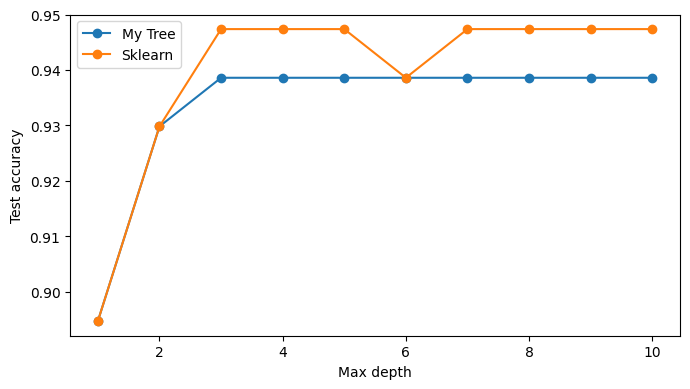

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,4))
plt.plot(df['depth'], df['my_tree'], marker='o', label='My Tree')
plt.plot(df['depth'], df['sklearn'], marker='o', label='Sklearn')
plt.xlabel('Max depth')
plt.ylabel('Test accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('../Results/benchmark_depth.png', dpi=160)
plt.show()

In [11]:
print('\nMy tree:')
print_tree(my_tree.root, feature_names=feature_names)

print('\nSklearn tree:')
print(export_text(sk_tree, feature_names=feature_names))

print('\nRoot split comparison:')
my_root = getattr(my_tree.root, 'feature_index', None)
sk_root = sk_tree.tree_.feature[0]
print('my tree root feature:', my_root)
print('sklearn root feature:', sk_root)
print('my tree root threshold:', getattr(my_tree.root, 'threshold', None))
print('sklearn root threshold:', sk_tree.tree_.threshold[0]) 


My tree:
If feature[7] < 0.05128:
  If feature[20] < 16.83:
    If feature[10] < 0.62555:
      If feature[24] < 0.17765:
        If feature[14] < 0.003309:
          Leaf: value = 0
        Else:
          Leaf: value = 0
      Else:
        Leaf: value = 1
    Else:
      If feature[4] < 0.09068:
        Leaf: value = 0
      Else:
        Leaf: value = 1
  Else:
    If feature[1] < 16.189999999999998:
      Leaf: value = 0
    Else:
      If feature[17] < 0.010125499999999999:
        Leaf: value = 1
      Else:
        Leaf: value = 0
Else:
  If feature[27] < 0.14655:
    If feature[22] < 115.25:
      If feature[1] < 21.055:
        Leaf: value = 0
      Else:
        Leaf: value = 1
    Else:
      Leaf: value = 1
  Else:
    If feature[16] < 0.13565:
      Leaf: value = 1
    Else:
      Leaf: value = 0

Sklearn tree:
|--- feature[7] <= 0.05
|   |--- feature[20] <= 16.83
|   |   |--- feature[13] <= 48.70
|   |   |   |--- feature[24] <= 0.18
|   |   |   |   |--- feature[14] <= 0